# Section 3, Figure 1

Builds a coarse loss landscape over layerwise sparsity values on the sklearn digits classification task.

## Run Notes
- Run the notebook from top to bottom.
- Uses sklearn digits, so no dataset download is required.
- Produces both a 3D surface and a 2D heatmap.
- Random sampling is intentionally exposed in the experiment cells so readers can vary it.

## Setup

In [ ]:
import math

import numpy as np
import torch
import torch.autograd as autograd
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

# Prefer a GPU in Colab, fall back to Apple MPS when available, and use CPU otherwise.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

def signed_kaiming_constant_(
    tensor,
    a=0,
    mode="fan_in",
    nonlinearity="relu",
    k=0.5,
    sparsity=0.0,
):
    """Initialize frozen weights with signed Kaiming-style uniform samples.

    Optional `sparsity` zeroes out a fraction of initialized weights.
    """
    fan = nn.init._calculate_correct_fan(tensor, mode)
    gain = nn.init.calculate_gain(nonlinearity, a)
    std = gain / math.sqrt(fan)

    # The active subnetwork keeps a k-fraction of weights, so rescale by 1/sqrt(k).
    if k != 0:
        std *= 1 / math.sqrt(k)

    with torch.no_grad():
        tensor.uniform_(-std, std)
        if sparsity > 0:
            keep_mask = (torch.rand_like(tensor) > sparsity).float()
            tensor *= keep_mask
        return tensor

class GetSubnet(autograd.Function):
    """Straight-through top-k mask used by edge-popup."""

    @staticmethod
    def forward(ctx, scores, k=0.5):
        # Convert scores to a binary mask by keeping the largest k-fraction.
        out = scores.clone()
        _, idx = scores.flatten().sort()
        cutoff = int((1 - k) * scores.numel())
        flat_out = out.flatten()
        flat_out[idx[:cutoff]] = 0
        flat_out[idx[cutoff:]] = 1
        return out

    @staticmethod
    def backward(ctx, grad):
        # Straight-through estimator: pass score gradients through unchanged.
        return grad, None

class LinearSubnet(nn.Linear):
    """Linear layer with frozen weights and trainable scores that choose the mask."""

    def __init__(
        self,
        in_features,
        out_features,
        init=signed_kaiming_constant_,
        k=0.5,
        extra_capacity=0,
        double=True, sparsity=0.0,
        **kwargs,
    ):
        super().__init__(in_features, out_features, **kwargs)
        multiplier = 2 if double else 1
        self.k = k

        # Scores can be wider than the weight matrix; only the realized weight slice is used.
        self.scores = nn.Parameter(
            torch.randn(out_features, multiplier * in_features + extra_capacity)
        )
        init(self.weight, sparsity=sparsity)
        self.weight.requires_grad_(False)

        if self.bias is not None:
            self.bias_scores = nn.Parameter(
                torch.randn(multiplier + extra_capacity, out_features)
            )
            self.bias.requires_grad_(False)

    def forward(self, x):
        weight_mask = GetSubnet.apply(self.scores.abs(), self.k)
        weight = self.weight * weight_mask[:, : self.weight.shape[-1]]

        if self.bias is None:
            return F.linear(x, weight)

        bias_mask = GetSubnet.apply(self.bias_scores.abs(), self.k)
        bias = self.bias * bias_mask[1, : self.bias.shape[-1]]
        return F.linear(x, weight, bias)


class Network(nn.Module):
    """Small MLP assembled from masked LinearSubnet layers."""

    def __init__(
        self,
        layer_sizes,
        init=signed_kaiming_constant_,
        bias=True,
        double=True,
        extra_capacity=0,
        sparsity=0.0,
    ):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            *[
                block
                for layer in layer_sizes
                for block in [
                    LinearSubnet(
                        layer[0],
                        layer[1],
                        init=init,
                        bias=bias,
                        double=double,
                        extra_capacity=extra_capacity,
                        sparsity=sparsity,
                    ),
                    nn.ReLU(),
                ]
            ][:-1]
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)

    def set_ks(self, ks):
        """Update layerwise sparsity values for a grid-search or sweep."""
        k_iter = iter(ks)
        for layer in self.layers:
            if isinstance(layer, LinearSubnet):
                layer.k = next(k_iter)

Using cpu device


## Experiment and Figure

Total grid points: 441


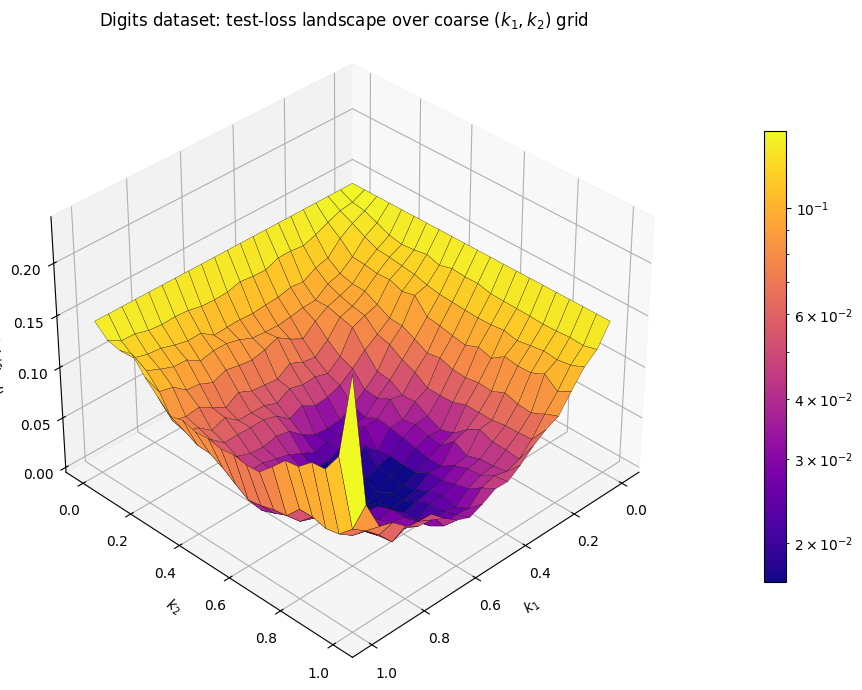

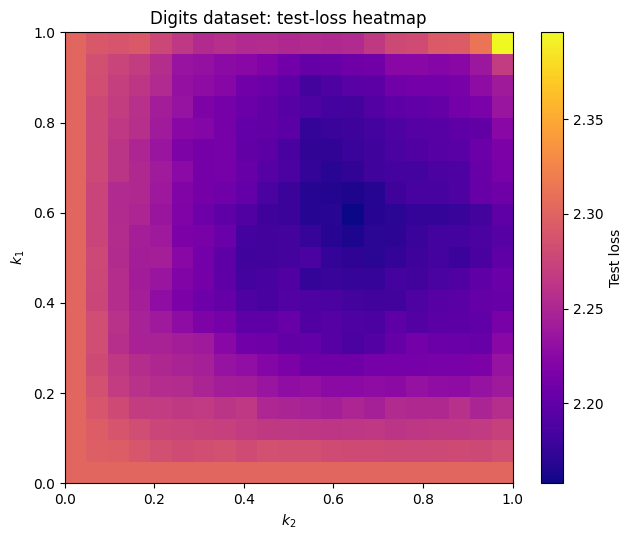

In [ ]:
# Experiment outline:
# 1. Load sklearn digits and wrap it in torch DataLoaders.
# 2. Sweep a coarse grid of k values for the two masked layers.
# 3. Train/evaluate each grid point and plot the resulting loss landscape.

# ------------------------------------------------------------
# Small dataset: sklearn digits (8x8 grayscale images, 10 classes)
# ------------------------------------------------------------
device = 'cuda' if torch.cuda.is_available() else 'cpu'

digits = load_digits()
X = digits.data.astype(np.float32) / 16.0   # normalize to [0,1]
y = digits.target.astype(np.int64)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test  = torch.tensor(X_test, dtype=torch.float32)
y_test  = torch.tensor(y_test, dtype=torch.long)

batch_size = 32
train_dataloader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
test_dataloader  = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

# ------------------------------------------------------------
# Evaluation helper
# ------------------------------------------------------------
def test(dataloader, model, loss_fn):
    model.eval()
    num_batches = len(dataloader)
    test_loss = 0.0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()

    test_loss /= num_batches
    return test_loss

# ------------------------------------------------------------
# Much smaller model + coarse k-grid
# ------------------------------------------------------------
num_epochs = 20

# 8x8 input -> 64 features
# Use a tiny hidden width so the search is manageable
layer_sizes = [[64, 32], [32, 10]]

model_brute = Network(layer_sizes, bias=False, double=False, sparsity=0.5).to(device)

# Save initial parameters so every grid point starts from the same place
W0 = model_brute.layers[0].weight.data.clone().to(device)
W1 = model_brute.layers[2].weight.data.clone().to(device)
S0 = model_brute.layers[0].scores.data.clone().to(device)
S1 = model_brute.layers[2].scores.data.clone().to(device)

# ------------------------------------------------------------
# Instead of all integer k-counts, use a coarse fraction grid
# This is the main speedup.
# ------------------------------------------------------------
k1_vals = np.linspace(0.0, 1.0, 21)   # 0.0, 0.1, ..., 1.0
k2_vals = np.linspace(0.0, 1.0, 21)

Z = np.zeros((len(k1_vals), len(k2_vals)))

print(f"Total grid points: {len(k1_vals) * len(k2_vals)}")

loss_fn = nn.CrossEntropyLoss()

for i, k1 in enumerate(k1_vals):
    for j, k2 in enumerate(k2_vals):
        # Reset model to identical initialization
        model_brute.layers[0].weight.data = W0.clone()
        model_brute.layers[2].weight.data = W1.clone()
        model_brute.layers[0].scores.data = S0.clone()
        model_brute.layers[2].scores.data = S1.clone()

        model_brute.set_ks([float(k1), float(k2)])

        optimizer_brute = torch.optim.Adam(model_brute.parameters(), lr=1e-3)

        for e in range(num_epochs):
            model_brute.train()
            for X, y in train_dataloader:
                X, y = X.to(device), y.to(device)
                optimizer_brute.zero_grad()
                pred = model_brute(X)
                loss = loss_fn(pred, y)
                loss.backward()
                optimizer_brute.step()

        Z[i, j] = test(test_dataloader, model_brute, loss_fn)

# ------------------------------------------------------------
# Build the k-grid
# ------------------------------------------------------------
K1, K2 = np.meshgrid(k1_vals, k2_vals, indexing='ij')

# ------------------------------------------------------------
# Plot 3D mesh surface
# ------------------------------------------------------------
Z_centered = Z - Z.min()
Z_safe = Z_centered + 1e-12

vmax = np.percentile(Z_safe, 95)
vmin = np.percentile(Z_safe, 5)
if vmin <= 0:
    vmin = 1e-12

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    K1, K2, Z_safe,
    cmap='plasma',
    norm=LogNorm(vmin=vmin, vmax=vmax),
    edgecolor='k',
    linewidth=0.2,
    antialiased=True
)

ax.view_init(35, 45)
ax.set_xlabel(r'$k_1$')
ax.set_ylabel(r'$k_2$')
ax.set_zlabel('Loss (shifted)', labelpad=6)
ax.set_title('Digits dataset: test-loss landscape over coarse $(k_1,k_2)$ grid')

fig.colorbar(surf, ax=ax, shrink=0.7, pad=0.10)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Optional 2D heatmap too (often easier to read in a paper)
# ------------------------------------------------------------
plt.figure(figsize=(6.5, 5.5))
plt.imshow(Z, origin='lower', aspect='auto', cmap='plasma',
           extent=[k2_vals.min(), k2_vals.max(), k1_vals.min(), k1_vals.max()])
plt.xlabel(r'$k_2$')
plt.ylabel(r'$k_1$')
plt.title('Digits dataset: test-loss heatmap')
plt.colorbar(label='Test loss')
plt.tight_layout()
plt.show()